# 📜 Log Parser & Alerter - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/log-parser/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/log-parser/demo.ipynb)

> *"We grep through logs manually."*

This tool parses **mixed-format** logs (JSON, syslog-style, Apache/nginx access
logs) into structured records, classifies severity, surfaces the top errors, and
runs an **alert-rule engine** so a spike pages someone instead of scrolling past.

**What we cover**
1. Parse one line of each format
2. Parse a realistic mixed log
3. Summarize: levels + top errors
4. Alert rules that fire on a spike
5. Visualize the severity timeline


## Step 1 - One parser, several formats

Each line is tried against JSON → generic `LEVEL` → access-log → keyword
fallback. Severity is normalized to a number so rules and charts are uniform.


In [1]:
from __future__ import annotations

import json, re
from dataclasses import dataclass, field
from typing import Dict, List, Optional

LEVELS = ["DEBUG", "INFO", "WARNING", "WARN", "ERROR", "CRITICAL", "FATAL"]
SEVERITY = {"DEBUG":10,"INFO":20,"WARNING":30,"WARN":30,"ERROR":40,"CRITICAL":50,"FATAL":50}
_GENERIC = re.compile(r"^(?P<ts>\d{4}-\d{2}-\d{2}[ T]\d{2}:\d{2}:\d{2}(?:[.,]\d+)?)\s+(?P<level>" + "|".join(LEVELS) + r")\b[:\s]+(?P<msg>.*)$", re.IGNORECASE)
_ACCESS = re.compile(r'^(?P<ip>\S+)\s+\S+\s+\S+\s+\[(?P<ts>[^\]]+)\]\s+"(?P<req>[^"]*)"\s+(?P<status>\d{3})\s+(?P<size>\S+)')

@dataclass
class LogRecord:
    raw: str; level: str="UNKNOWN"; severity: int=0
    timestamp: Optional[str]=None; message: str=""; source_format: str="unparsed"
    fields: Dict[str,str]=field(default_factory=dict)

def _level_from_status(s):
    return "ERROR" if s>=500 else "WARNING" if s>=400 else "INFO"

def parse_line(line: str) -> LogRecord:
    line = line.rstrip("\n")
    if not line.strip():
        return LogRecord(raw=line, source_format="blank")
    s = line.strip()
    if s.startswith("{"):
        try:
            o = json.loads(s); lv = str(o.get("level") or o.get("severity") or "INFO").upper()
            return LogRecord(line, lv if lv in SEVERITY else "INFO", SEVERITY.get(lv,20),
                             str(o.get("timestamp") or o.get("time") or "") or None,
                             str(o.get("message") or o.get("msg") or s), "json")
        except json.JSONDecodeError:
            pass
    m = _GENERIC.match(line)
    if m:
        lv = m.group("level").upper()
        return LogRecord(line, lv, SEVERITY.get(lv,0), m.group("ts"), m.group("msg").strip(), "generic")
    m = _ACCESS.match(line)
    if m:
        st = int(m.group("status")); lv = _level_from_status(st)
        return LogRecord(line, lv, SEVERITY[lv], m.group("ts"), f'{m.group("req")} -> {st}', "access")
    up = line.upper()
    for lv in sorted(SEVERITY, key=lambda x:-SEVERITY[x]):
        if re.search(rf"\b{lv}\b", up):
            return LogRecord(line, lv, SEVERITY[lv], None, line.strip(), "keyword")
    return LogRecord(line, "UNKNOWN", 0, None, line.strip(), "unparsed")

for ln in ['2026-06-20 10:16:23 ERROR database connection timeout',
           '{"timestamp":"2026-06-20T10:16:25","level":"ERROR","message":"db timeout"}',
           '127.0.0.1 - - [20/Jun/2026:10:17:00 +0000] "GET /api/orders HTTP/1.1" 500 1320']:
    r = parse_line(ln); print(f"{r.source_format:8s} {r.level:8s} sev={r.severity} | {r.message}")

generic  ERROR    sev=40 | database connection timeout
json     ERROR    sev=40 | db timeout
access   ERROR    sev=40 | GET /api/orders HTTP/1.1 -> 500


## Step 2 - Parse a realistic mixed log

In [2]:
SAMPLE = """2026-06-20 10:15:01 INFO service started on :8000
2026-06-20 10:15:04 INFO request /health 200
2026-06-20 10:16:22 WARNING slow query took 1200ms
2026-06-20 10:16:23 ERROR database connection timeout
{"timestamp":"2026-06-20T10:16:25","level":"ERROR","message":"database connection timeout"}
2026-06-20 10:16:31 ERROR database connection timeout
127.0.0.1 - - [20/Jun/2026:10:17:00 +0000] "GET /api/orders HTTP/1.1" 500 1320
2026-06-20 10:17:10 CRITICAL out of memory, worker killed
2026-06-20 10:18:00 INFO request /health 200"""

records = [parse_line(l) for l in SAMPLE.splitlines() if l.strip()]
print(f"parsed {len(records)} lines")

parsed 9 lines


## Step 3 - Summarize: levels + the noisiest errors

In [3]:
def summarize(records):
    by_level, errs = {}, {}
    for r in records:
        by_level[r.level] = by_level.get(r.level,0)+1
        if r.severity >= SEVERITY["ERROR"]:
            errs[r.message] = errs.get(r.message,0)+1
    return {"total":len(records), "by_level":dict(sorted(by_level.items(), key=lambda x:-SEVERITY.get(x[0],0))),
            "error_count":sum(1 for r in records if r.severity>=SEVERITY["ERROR"]),
            "top_errors":sorted(errs.items(), key=lambda x:-x[1])[:10]}

summary = summarize(records)
print("by level :", summary["by_level"])
print("errors+  :", summary["error_count"])
print("top error:", summary["top_errors"][0])

by level : {'CRITICAL': 1, 'ERROR': 4, 'WARNING': 1, 'INFO': 3}
errors+  : 5
top error: ('database connection timeout', 3)


## Step 4 - Alert rules that fire on a spike

A rule = minimum severity + a count threshold + an optional substring. The
"timeout" rule fires because 3 timeout errors cross the threshold of 2.


In [4]:
@dataclass
class AlertRule:
    name: str; min_level: str="ERROR"; threshold: int=1; contains: Optional[str]=None

def evaluate_rules(records, rules):
    out = []
    for rule in rules:
        floor = SEVERITY.get(rule.min_level.upper(), 40)
        matches = [r for r in records if r.severity>=floor and (rule.contains is None or rule.contains.lower() in r.message.lower())]
        out.append({"rule":rule.name, "matches":len(matches), "threshold":rule.threshold,
                    "fired":len(matches)>=rule.threshold, "sample":matches[0].message if matches else None})
    return out

rules = [AlertRule("timeout spike","ERROR",2,"timeout"), AlertRule("any critical","CRITICAL",1)]
for res in evaluate_rules(records, rules):
    flag = "🚨 FIRED" if res["fired"] else "quiet"
    print(f"{flag:9s} {res['rule']:16s} {res['matches']}/{res['threshold']}  ({res['sample']})")

🚨 FIRED   timeout spike    3/2  (database connection timeout)
🚨 FIRED   any critical     1/1  (out of memory, worker killed)


## Step 5 - Severity over time, visualized

Red dots are errors/critical; you can see the incident cluster between 10:16 and
10:17 - exactly where the alert fires.


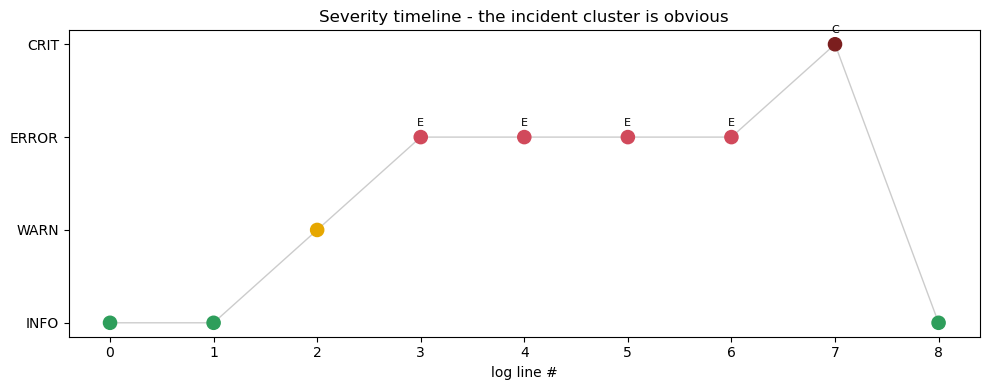

In [5]:
import matplotlib.pyplot as plt

color = {"INFO":"#2e9e5b","WARNING":"#e6a700","ERROR":"#d1495b","CRITICAL":"#7b1e1e"}
xs = list(range(len(records)))
ys = [r.severity for r in records]
cs = [color.get(r.level, "#999") for r in records]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xs, ys, color="#ccc", lw=1, zorder=1)
ax.scatter(xs, ys, c=cs, s=90, zorder=2)
for x, r in zip(xs, records):
    if r.severity >= SEVERITY["ERROR"]:
        ax.annotate(r.level[0], (x, r.severity), textcoords="offset points", xytext=(0,8), ha="center", fontsize=8)
ax.set_yticks([20,30,40,50]); ax.set_yticklabels(["INFO","WARN","ERROR","CRIT"])
ax.set_xlabel("log line #"); ax.set_title("Severity timeline - the incident cluster is obvious")
plt.tight_layout(); plt.savefig("severity.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary

- One parser handles JSON, generic `LEVEL`, and Apache/nginx access logs, normalizing severity to a number.
- `summarize` surfaces level counts and the noisiest error messages.
- `evaluate_rules` is a tiny alert engine: severity floor + threshold + optional substring → fired/quiet.

This is the engine behind the Streamlit app in `app.py` - and a reusable
**Observability** module for the platform shell.


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run the dashboard:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
Paste your own logs, set an alert rule in the sidebar, and watch it fire.
